In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os


/kaggle/input/penguins/penguins.csv


In [ ]:
for dirname, _, filenames in os.walk('./data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
df = pd.read_csv("./data/penguins/penguins.csv")


In [3]:
adelie_df= df[df['species'] == 'Adelie']
chinstrap_df = df[df['species'] == 'Chinstrap']
gentoo_df = df[df['species'] == 'Gentoo']
biscoe_df = df[df['island'] == 'Biscoe']
dream_df = df[df['island'] == 'Dream']
torgersen_df = df[df['island'] == 'Torgersen']

Data exploration

In [4]:
print(f"There are {df['id'].count()} penguins in this dataset.")
print(f"There are {df[df['species'] == 'Adelie']['id'].count()} Adelie penguins, {df[df['species'] == 'Chinstrap']['id'].count()} Chinstrap, and {df[df['species'] == 'Gentoo']['id'].count()} Gentoo penguins in this dataset.")
adelie_islands = df[df['species'] == 'Adelie']['island'].unique()

print(f"Adelie penguins live on the {adelie_islands} islands.")

There are 344 penguins in this dataset.
There are 152 Adelie penguins, 68 Chinstrap, and 124 Gentoo penguins in this dataset.
Adelie penguins live on the ['Torgersen' 'Biscoe' 'Dream'] islands.


In [5]:
df.groupby(['island', 'sex', 'species']).size().unstack(fill_value=0)

species           Adelie  Chinstrap  Gentoo
island    sex                              
Biscoe    female      22          0      58
          male        22          0      61
Dream     female      27         34       0
          male        28         34       0
Torgersen female      24          0       0
          male        23          0       0

In [6]:
counts = adelie_df.groupby(['island', 'sex']).size().unstack(fill_value=0)
styled_table = (
    counts.style
    .set_caption("Demographic Count of Individuals by Island")
    .set_properties(subset=['female'], **{'background-color': '#F08080'})
    .set_properties(subset=['male'], **{'background-color': '#ADD8E6'})  
    .format(precision=0)
    .set_properties(**{'font-size': '10pt'})
)

styled_table

sex,female,male
island,,
Biscoe,22,22
Dream,27,28
Torgersen,24,23


Flipper length vs body mass in g in all three species

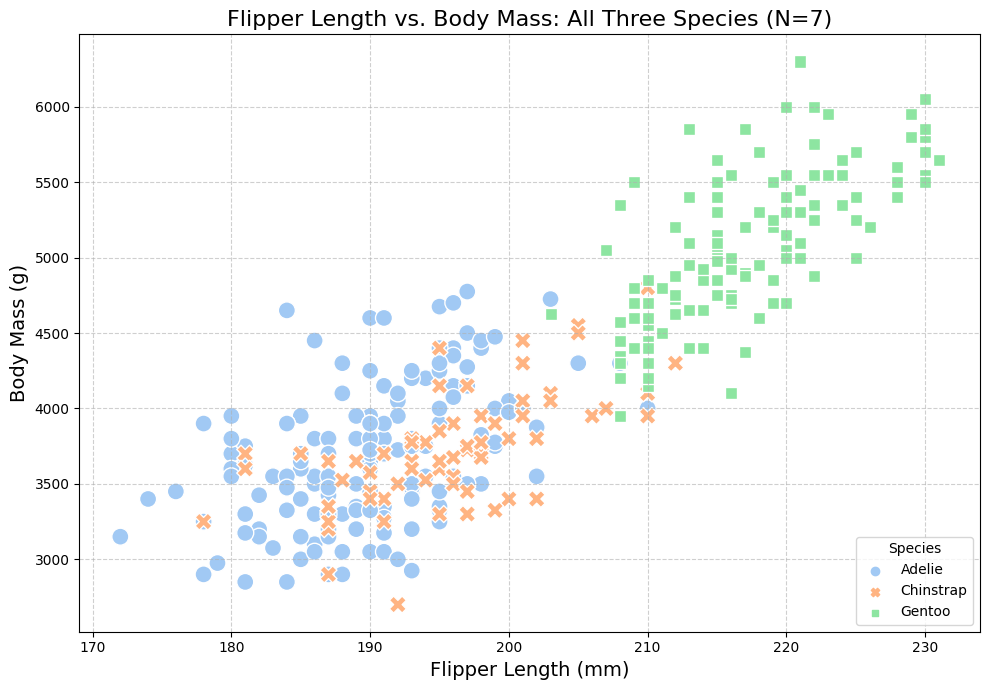

In [7]:
combined_df = pd.concat([adelie_df, chinstrap_df, gentoo_df], ignore_index=True)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=combined_df,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='species',
    style='species',
    s=150,
    palette='pastel' 
)

plt.title('Flipper Length vs. Body Mass: All Three Species (N=7)', fontsize=16)
plt.xlabel('Flipper Length (mm)', fontsize=14)
plt.ylabel('Body Mass (g)', fontsize=14)
plt.legend(title='Species', loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('all_species_flipper_mass_scatter.png')

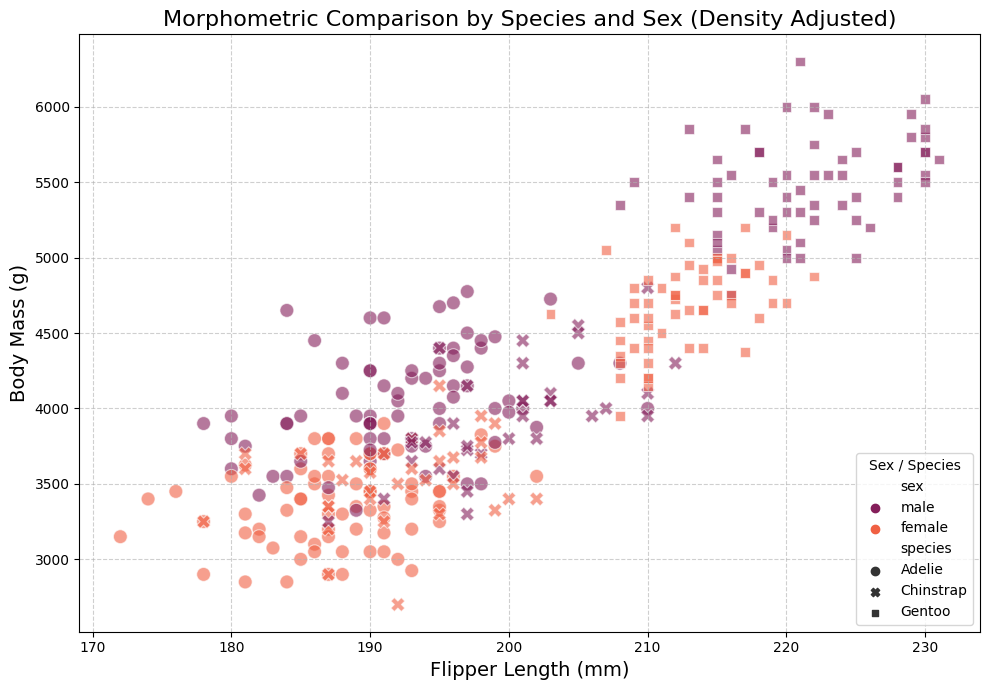

In [8]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=combined_df,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='sex', 
    style='species', 
    s=100, 
    alpha=0.6,      
    palette='rocket'
)

plt.title('Morphometric Comparison by Species and Sex (Density Adjusted)', fontsize=16)
plt.xlabel('Flipper Length (mm)', fontsize=14)
plt.ylabel('Body Mass (g)', fontsize=14)
plt.legend(title='Sex / Species', loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


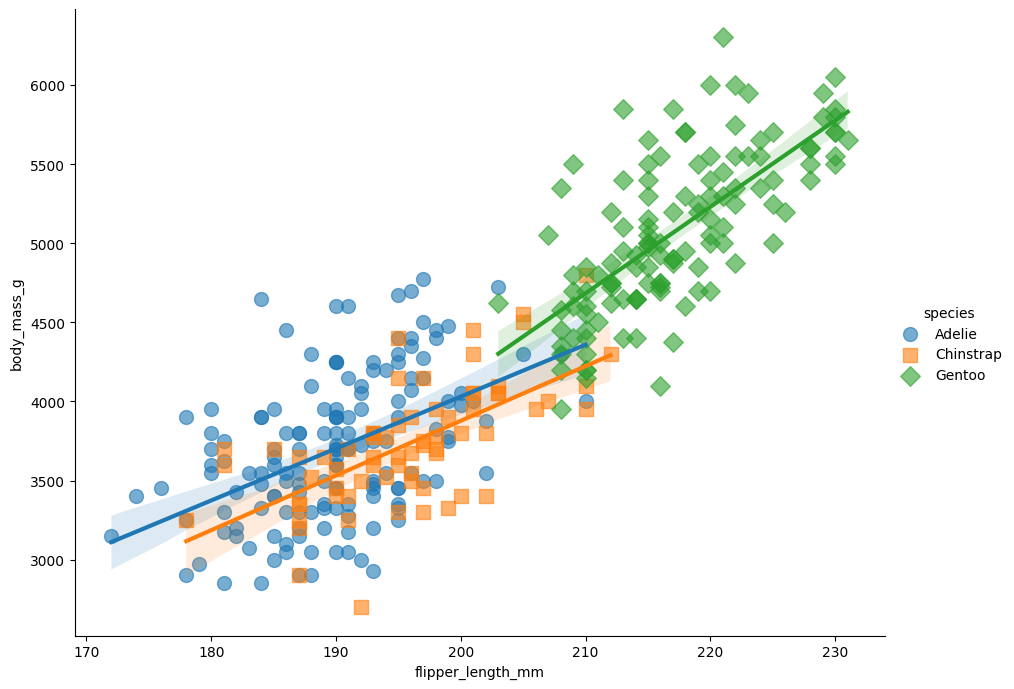

In [9]:
g = sns.lmplot(
    data=combined_df,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='species',     
    markers=['o', 's', 'D'], 
    height=7,
    aspect=1.3,
    scatter_kws={'s': 100, 'alpha': 0.6}, 
    line_kws={'lw': 3}
)